# Aitor González Barrera | Víctor Sánchez Melero

## Red que clasifica imagenes para detectar la comida de la que trata la imagen y decir al usuario si sus ingredientes de preparación contienen o no alérgenos

# 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
import tensorflow as tf
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 2. Datasets

In [2]:
ingredientes = pd.read_csv('ingredientes_allrecipes.csv')
ingredientes.head(10)

,Clase_Plato,Ingredientes_Allrecipes
0,apple_pie,1 9-inch pie crust | 5 large Granny Smith appl...
1,baby_back_ribs,"3 pounds baby back ribs, trimmed | salt and gr..."
2,baklava,1 cup butter | 1 pound chopped nuts | 1 teaspo...
3,beef_carpaccio,"6 2-inch beets, trimmed, as evenly sized as po..."
4,beef_tartare,1 pound finely ground beef tenderloin | 1 teas...
5,beet_salad,"6 large beets, trimmed | 0.25 cup extra virgin..."
6,beignets,1 (.25 ounce) package active dry yeast | 1.5 c...
7,bibimbap,2 tablespoons sesame oil | 1 cup carrot matchs...
8,bread_pudding,3 cups whole milk | 1.5 cups white sugar | 0.2...
9,breakfast_burrito,1 pound bacon | 10 eggs | 1 (16 ounce) can ref...


Tal y como nos ha devuelto el dataset el scraping, aparecen los ingredientes de las comidas con las cantidades necesarias, como esa informacion se escapa del estudio propuesto del proyecto, vamos a hacer una limpieza de texto para dejar solo los ingredientes.

In [3]:
warnings.filterwarnings('ignore')
def limpiar_ingrediente(ingrediente):
    # Pasamos a minúscula y quitamos espacios a los lados
    ing = str(ingrediente).lower().strip()
    
    # 1. Eliminar información entre paréntesis
    ing = re.sub(r'\(.*?\)', '', ing)
    
    # 2. Lista de palabras de preparación y adjetivos de estado a ignorar
    preparaciones = [
        r'\bpeeled\b', r'\bcored\b', r'\bsliced\b', r'\bminced\b', r'\bchopped\b', 
        r'\bto taste\b', r'\btrimmed\b', r'\bdivided\b', r'\bdrained\b', r'\bcrushed\b', 
        r'\bsoftened\b', r'\bbeaten\b', r'\bmelted\b', r'\bcooked\b', r'\bcooled\b', 
        r'\brinsed\b', r'\bdiced\b', r'\bgrated\b', r'\bfreshly\b', r'\bfresh\b', 
        r'\bfinely\b', r'\bground\b', r'\bprepared\b', r'\bcut into.*?\b'
    ]
    
    for p in preparaciones:
        ing = re.sub(p, '', ing)
        
    # 3. Eliminar números y fracciones
    ing = re.sub(r'\d+(?:/\d+|\.\d+)?', '', ing)
    
    # 4. Lista de unidades y tamaños
    unidades = [
        r'\bcups?\b', r'\bteaspoons?\b', r'\btablespoons?\b', r'\bpounds?\b',
        r'\bounces?\b', r'\bpints?\b', r'\bquarts?\b', r'\bgallons?\b',
        r'\bpinches?\b', r'\bdashes?\b', r'\bslices?\b', r'\bpackages?\b',
        r'\bcans?\b', r'\bcloves?\b', r'\bstalks?\b', r'\bfluid\b', r'\bjar\b',
        r'\bbottle\b', r'\bcontainer\b', r'\bheads?\b', r'\bbunches?\b',
        r'\blarge\b', r'\bmedium\b', r'\bsmall\b', r'\bwhole\b', r'\bhalf\b',
        r'\bhalves\b', r'\bthick\b', r'\bpinch\b', r'\bdash\b', r'\binches?\b',
        r'\bpiece\b', r'\bpieces\b', r'\benvelope\b', r'\bsquare\b', r'\bgrams?\b',
        r'\bml\b', r'\bliter\b', r'\bliters\b', r'\bkg\b', r'\b-inch\b', r'\binch\b'
    ]
    
    patron_unidades = '|'.join(unidades)
    ing = re.sub(patron_unidades, '', ing)
    
    # 5. Limpiar signos de puntuación sueltos (comas y guiones que hayan quedado)
    ing = re.sub(r'[,\-]', ' ', ing)
    
    # 6. Limpieza final de espacios
    ing = re.sub(r'\s+', ' ', ing).strip()
    
    return ing
def limpiar_lista_ingredientes(cadena_ingredientes):
    if not isinstance(cadena_ingredientes, str):
        return cadena_ingredientes
        
    # Reemplazar la palabra "and" por "|" para que divida cosas como "salt and ground black pepper"
    cadena_ingredientes = re.sub(r'\band\b', '|', cadena_ingredientes)
    
    lista = cadena_ingredientes.split('|')
    lista_limpia = [limpiar_ingrediente(i) for i in lista]
    
    # Filtrar elementos vacíos o de un solo carácter (errores de regex)
    lista_limpia = [i for i in lista_limpia if i and len(i) > 1] 
    
    # Quitar posibles duplicados (por ejemplo si dice "salt | sea salt" y se limpian quedando igual)
    lista_final = []
    for i in lista_limpia:
        if i not in lista_final:
            lista_final.append(i)
            
    return ' | '.join(lista_final)
# Cargar el dataset original
df = pd.read_csv('ingredientes_allrecipes.csv')
# Aplicar la limpieza creando temporalmente una nueva columna
df['Ingredientes_Limpios'] = df['Ingredientes_Allrecipes'].apply(limpiar_lista_ingredientes)
# Nos quedamos con la clase del plato y los ingredientes limpios
df_limpio = df[['Clase_Plato', 'Ingredientes_Limpios']]
df_limpio.rename(columns={'Ingredientes_Limpios': 'Ingredientes_Allrecipes'}, inplace=True)
# Guardar en un nuevo archivo .csv
nombre_archivo_limpio = 'ingredientes_allrecipes_limpio.csv'
df_limpio.to_csv(nombre_archivo_limpio, index=False)
print(f"Dataset limpiado y guardado exitosamente como: {nombre_archivo_limpio}")
df_limpio.head(10)

Dataset limpiado y guardado exitosamente como: ingredientes_allrecipes_limpio.csv


,Clase_Plato,Ingredientes_Allrecipes
0,apple_pie,pie crust | granny smith apples | white sugar ...
1,baby_back_ribs,baby back ribs | salt | black pepper | water |...
2,baklava,butter | nuts | cinnamon | phyllo dough | wate...
3,beef_carpaccio,beets as evenly sized as possible | soft goat ...
4,beef_tartare,beef tenderloin | brown mustard | hot pepper s...
5,beet_salad,beets | extra virgin olive oil | salt | black ...
6,beignets,active dry yeast | warm water | evaporated mil...
7,bibimbap,sesame oil | carrot matchsticks | zucchini mat...
8,bread_pudding,milk | white sugar | butter | eggs | light bro...
9,breakfast_burrito,bacon | eggs | refried beans | shredded chedda...


# 3. Imagenes

Cargando subconjunto de Entrenamiento para 30 clases...
Found 30000 files belonging to 30 classes.
Using 24000 files for training.

Cargando subconjunto de Validación...
Found 30000 files belonging to 30 classes.
Using 6000 files for validation.

¡Carga completada! El modelo solo entrenará para 30 clases.


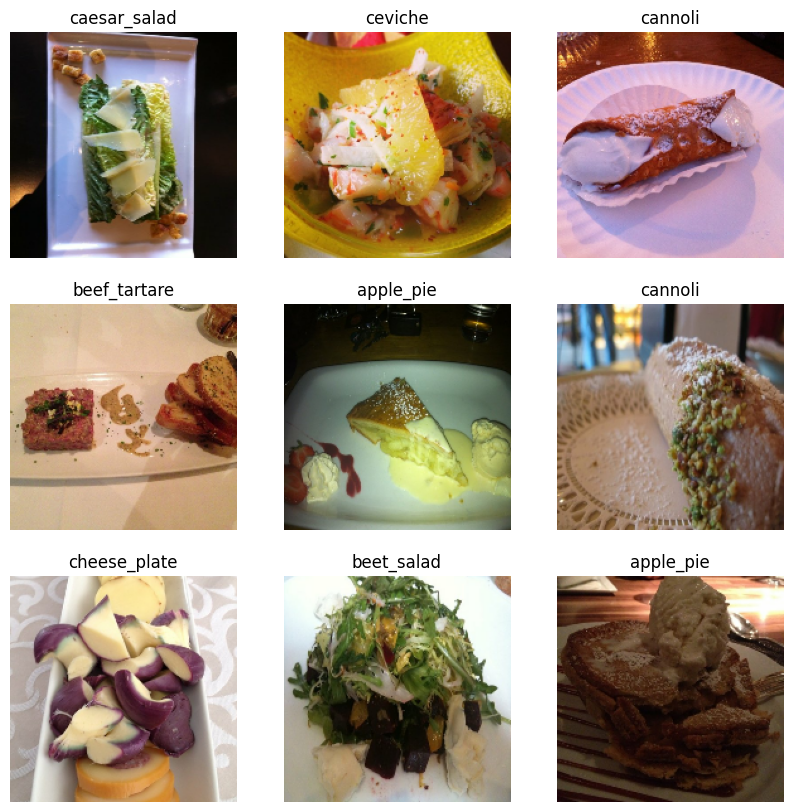

In [4]:
# Ruta principal donde están las carpetas de las clases
data_dir = 'food-101/images'

# 1. Obtenemos todas las carpetas ignorando archivos ocultos como .DS_Store
todas_las_clases = [
    nombre for nombre in os.listdir(data_dir) 
    if not nombre.startswith('.') and os.path.isdir(os.path.join(data_dir, nombre))
]
todas_las_clases = sorted(todas_las_clases)
# Nos quedamos con las 50 primeras clases
clases_reducidas = todas_las_clases[:30]


def cargar_datasets_imagenes(data_dir, img_height=180, img_width=180, batch_size=32, validation_split=0.2):
    """
    Lee la estructura de carpetas y carga las imágenes como tf.data.Dataset
    Se redimensionan a 224x224 (estándar para muchos modelos preentrenados como ResNet o MobileNet).
    """
    print(f"Cargando subconjunto de Entrenamiento para {len(clases_reducidas)} clases...")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset="training",
        seed=123, # Semilla para asegurar que la división sea consistente
        image_size=(img_height, img_width),
        batch_size=batch_size,
        class_names=clases_reducidas
    )
    print("\nCargando subconjunto de Validación...")
    val_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        class_names=clases_reducidas
    )
    
    # Nombres de las carpetas (que equivalen a las etiquetas o clases)
    class_names = train_ds.class_names
    print(f"\n¡Carga completada! El modelo solo entrenará para {len(class_names)} clases.")
    
     # --- OPTIMIZACIÓN Y REDUCCIÓN DE TAMAÑO ---
    AUTOTUNE = tf.data.AUTOTUNE
    
    # 1. ELIMINAMOS .cache() para evitar que tu memoria RAM colapse. 
    train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
    
    # 2. LIMITAMOS A LA MITAD LAS IMÁGENES POR ÉPOCA (Para que vaya más rápido)
    # Calculamos cuántos lotes (batches) hay en total y tomamos solo la mitad (aprox. 40k imágenes)
    total_train_batches = tf.data.experimental.cardinality(train_ds).numpy()
    train_ds = train_ds.take(total_train_batches // 2)

    return train_ds, val_ds, class_names
    
# 1. Llamamos a la función
train_dataset, val_dataset, nombres_clases = cargar_datasets_imagenes(data_dir)
# 2. (Opcional) Visualizar un par de imágenes para confirmar que se ven bien
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1): # Coge un batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(nombres_clases[labels[i]])
        plt.axis("off")

### 4. Arquitectura de la Red Neuronal Convolucional (CNN)
He diseñado una arquitectura clásica de red convolucional desde cero.
- **Rescaling**: Normaliza los valores de los píxeles de [0, 255] a un rango de [0, 1] para que la red procese mejor los números.
- **Conv2D + MaxPooling2D**: Las capas convolucionales extraen características (bordes, texturas) y las de *Pooling* reducen la resolución espacial, quedándose con la información más relevante y reduciendo la carga computacional.
- **Dropout**: Apaga aleatoriamente un porcentaje de las neuronas durante el entrenamiento para evitar el *overfitting*.
- **Dense**: La capa final tiene tantas neuronas como clases tenemos, con una activación *softmax* para darnos probabilidades.


In [5]:
# Guardamos el número de clases dinámicamente
num_classes = len(nombres_clases)

# 1. Cargamos el modelo preentrenado MobileNetV2 (sin las capas finales de clasificación)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)
# Congelamos los pesos base para aprovechar lo que ya sabe reconocer (bordes, formas, etc.)
base_model.trainable = False

# 1. Recuperamos el Data Augmentation (Imprescindible contra el overfitting)
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.2),
layers.RandomZoom(0.2),

# 2. Creación de la arquitectura del modelo
modelo_cnn = Sequential([
    # Normalización: MobileNetV2 espera píxeles escalados entre [-1, 1] en lugar de [0, 1]
    layers.Rescaling(1./127.5, offset=-1, input_shape=(180, 180, 3)),
    
    # Añadimos el modelo base preentrenado
    base_model,
    
    # Capa de agrupamiento: Sustituye a Flatten() reduciendo millones de parámetros a solo unos pocos cientos
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),
    
    # Capas de Clasificación finales
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5), # Regularización
    layers.Dense(num_classes, activation='softmax')
])



# modelo_cnn = Sequential([
#   layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  
#   # 1. Aumentación de datos MÁS AGRESIVA
#   layers.RandomFlip("horizontal"),
#   layers.RandomRotation(0.2),         # Subido a 20%
#   layers.RandomZoom(0.2),             # Subido a 20%
#   layers.RandomTranslation(0.1, 0.1), # NUEVO: Mueve la imagen de arriba a abajo y lados
    
#   # 2. Bloques Convolucionales con Regularización L2 y pequeños Dropouts
#   layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#   layers.BatchNormalization(),
#   layers.MaxPooling2D(),
#   layers.Dropout(0.1), # Apaga el 10% de las neuronas en este paso
    
#   layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#   layers.BatchNormalization(),
#   layers.MaxPooling2D(),
#   layers.Dropout(0.2), # Apaga el 20%
    
#   layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#   layers.BatchNormalization(),
#   layers.MaxPooling2D(),
#   layers.Dropout(0.2),
  
#   layers.Conv2D(256, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#   layers.BatchNormalization(),
#   layers.MaxPooling2D(),
#   layers.Dropout(0.3), # Apaga el 30%
    
#   layers.GlobalAveragePooling2D(),
    
#   layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
#   layers.BatchNormalization(),
#   layers.Dropout(0.5), # Regularización estricta final (50%)
    
#   layers.Dense(num_classes, activation='softmax')
# ])

# Ver el resumen de nuestra nueva arquitectura
modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,630 (9.89 MB)

 Trainable params: 335,646 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Para compilar el modelo, definiremos cómo queremos que "aprenda":
- **Optimizador (Adam)**: Es el motor que ajustará los pesos de la red. Adam es muy eficiente y estándar en la industria.
- **Función de Pérdida (Sparse Categorical Crossentropy)**: Como estamos clasificando en múltiples categorías (101 clases) y nuestras etiquetas son números enteros, esta es la función adecuada.
- **Métrica**: Nos fijaremos en la precisión (*Accuracy*).

In [6]:
modelo_cnn.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

Entrenar modelos profundos puede ser incierto. Utilizaremos la técnica de **Early Stopping** (Parada Temprana). Esto monitorizará la pérdida en el conjunto de validación (`val_loss`); si después de 5 épocas (iteraciones) la red deja de mejorar, se detendrá automáticamente el entrenamiento. Así ahorramos tiempo de computación y nos quedamos con los mejores pesos (evitando sobreentrenar).

In [7]:
parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,               # Si no mejora tras 5 épocas, para
    restore_best_weights=True # Se queda con la mejor versión de la red
)

Iniciamos el proceso de entrenamiento alimentando al modelo con nuestro dataset de imágenes por lotes (`epochs=20`). Debido al tamaño del conjunto de datos de comida, este proceso tomará tiempo dependiendo de los recursos del sistema (CPU/GPU).

In [8]:
# Número de iteraciones completas sobre todo el dataset
epocas = 20
# Iniciar entrenamiento
history = modelo_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epocas,
    callbacks=[parada_temprana]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 202ms/step - accuracy: 0.3229 - loss: 2.4789 - val_accuracy: 0.5643 - val_loss: 1.6372
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 191ms/step - accuracy: 0.4886 - loss: 1.8300 - val_accuracy: 0.5985 - val_loss: 1.5085
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 192ms/step - accuracy: 0.5305 - loss: 1.6658 - val_accuracy: 0.6065 - val_loss: 1.4366
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 191ms/step - accuracy: 0.5615 - loss: 1.5554 - val_accuracy: 0.6133 - val_loss: 1.4034
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 72s 192ms/step - accuracy: 0.5790 - loss: 1.4964 - val_accuracy: 0.6183 - val_loss: 1.3961
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 190ms/step - accuracy: 0.5897 - loss: 1.4595 - val_accuracy: 0.6232 - val_loss: 1.3814
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - accuracy: 0.6023 - loss: 1.4118 - val_accuracy: 0.6210 - val_loss: 1.3991
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 195ms/step - accuracy: 0.6087 - loss: 1

Una vez entrenada, es fundamental ver las curvas de aprendizaje. Comparamos cómo ha evolucionado la precisión y el error tanto para los datos que veía (Entrenamiento) como para los datos nuevos (Validación) para detectar si ha aprendido bien o si simplemente ha memorizado (overfitting).

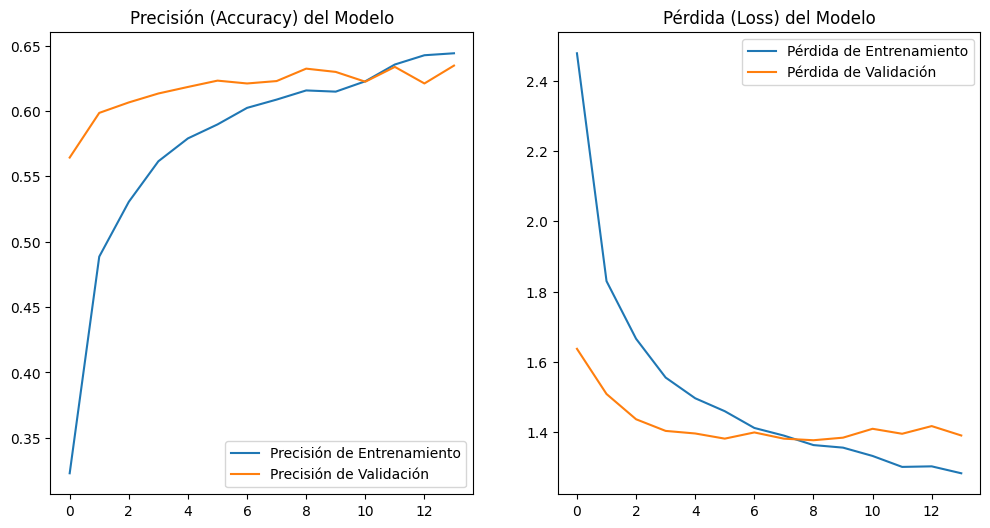

In [9]:
# Extraemos métricas del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
# Calculamos en qué época se detuvo realmente
epochs_range = range(len(acc))
# Graficamos la precisión
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión de Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy) del Modelo')
# Graficamos la pérdida (error)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss) del Modelo')
plt.show()